# Anchored Langevin on the multivariate Laplace, $J_a$ vs $J=0$

Multivariate version of `anchored_langevin_nonreversible.ipynb`, following its edited form: the chains
compared are **anchored with $J=0$ against anchored with the constant skew $J_a$**, same protocol
(N particles from a common start, $W_1$ to exact reference samples every iteration, terminal densities).

## Which multivariate Laplace?

"Multivariate Laplace" names more than one distribution, and the difference is exactly the thing this
project cares about — *where the potential fails to be differentiable*. Both are run below. Write
$\Sigma = LL^\top$ and $M=L^{-1}$.

| | potential $U(x)$ | $\pi$ | non-differentiable set | exact sampling |
|---|---|---|---|---|
| **Target A** — elliptical Laplace (exponential-power, $\beta=\tfrac12$) | $\lVert Mx\rVert_2=\sqrt{x^\top\Sigma^{-1}x}$ | $\propto e^{-\sqrt{x^\top\Sigma^{-1}x}}$ | the single point $\{0\}$ | $x=L\,r\,u$, $r\sim\mathrm{Gamma}(d,1)$, $u$ uniform on $S^{d-1}$ |
| **Target B** — correlated $\ell_1$ Laplace | $\lVert Mx\rVert_1$ | $\propto e^{-\lVert Mx\rVert_1}$ | $d$ hyperplanes $\{(Mx)_i=0\}$ | $x=Ly$, $y_i\stackrel{iid}\sim\mathrm{Laplace}(0,1)$ |

Target A is the usual elliptical generalisation and reduces to $|x|/b$ in $d=1$, but its kink sits at a
single point that the chain essentially never visits — a *weak* test of non-smoothness. Target B keeps the
kinks on a set the chain crosses constantly, and reduces to the product Laplace of the previous notebook
when $\Sigma$ is diagonal. Neither factorises: both carry correlation through $\Sigma$.

Throughout, $\Sigma = D C D$ with $D=\mathrm{diag}(0.5,1,2)$ (the anisotropy of the earlier notebooks) and
$C$ the equicorrelation matrix with $\rho=0.6$.

## Dynamics (unchanged)

$$dX_t=-(I+J)\,\nabla U_0(X_t)\,e^{\Delta(X_t)}\,dt+\sqrt2\,e^{\Delta(X_t)/2}\,dW_t,\qquad \Delta=U-U_0,$$

with the smoothed anchor obtained by rounding off the kink — $U_0=\sqrt{\lVert Mx\rVert_2^2+\delta^2}$ for
Target A, $U_0=\sum_i\sqrt{(Mx)_i^2+\delta^2}$ for Target B. In both cases $\Delta\le 0$ and is bounded
below, so $e^{\Delta}$ needs no clamping, and $\nabla U$ is never evaluated. $\pi$ is invariant for every
$a$ (proof in the previous notebook: the extra flux is $J\nabla e^{-U_0}$, and
$\nabla\!\cdot(J\nabla\varphi)=0$ for constant skew $J$).

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
torch.set_printoptions(precision=10)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, ks_2samp

In [2]:
# -----------------------------
# Settings
# -----------------------------
N        = 5000
max_iter = 2000
eta      = 5e-3      # transient regime: this is where J is supposed to matter
delta    = 0.1       # anchor smoothing
x_start  = 0.5
SEED     = 1006
A_MAIN   = 2.0

SCALES = [0.5, 1.0, 2.0]
RHO    = 0.6

In [3]:
# -----------------------------
# Covariance Sigma = D C D, and the constant skew J_a (the Gaussian notebook's J_fun)
# -----------------------------
def make_L(d, scales, rho):
    D = np.diag(scales)
    C = np.full((d, d), rho)
    np.fill_diagonal(C, 1.0)
    return np.linalg.cholesky(D @ C @ D)

def J_fun(dim, a):
    return torch.diag(a * torch.ones(dim - 1), diagonal=1) + torch.diag(-a * torch.ones(dim - 1), diagonal=-1)

L3 = make_L(3, SCALES, RHO)
print("Sigma =\n", np.round(L3 @ L3.T, 3))
print("\ncondition number of Sigma =", round(float(np.linalg.cond(L3 @ L3.T)), 1))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]

condition number of Sigma = 34.6


In [4]:
# -----------------------------
# Targets. kind = "ell" (Target A) or "l1" (Target B).
# U is never differentiated; only U0 is.
# -----------------------------
def build_target(kind, L):
    M = torch.tensor(np.linalg.inv(L))

    if kind == "ell":
        @torch.no_grad()
        def U(x):
            return torch.norm(x @ M.T, dim=1)
        @torch.no_grad()
        def U0(x):
            return torch.sqrt(torch.sum((x @ M.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def grad_U0(x):
            y = x @ M.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ M
    else:
        @torch.no_grad()
        def U(x):
            return torch.sum(torch.abs(x @ M.T), dim=1)
        @torch.no_grad()
        def U0(x):
            return torch.sum(torch.sqrt((x @ M.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def grad_U0(x):
            y = x @ M.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ M

    return U, U0, grad_U0

# -----------------------------
# Exact reference samples (no rejection needed for either target)
# -----------------------------
def sample_target(kind, L, size, rng):
    d = L.shape[0]
    if kind == "ell":
        r = rng.gamma(d, 1.0, size)                       # radial density ~ r^{d-1} e^{-r}
        u = rng.normal(size=(size, d))
        u /= np.linalg.norm(u, axis=1, keepdims=True)     # uniform on the sphere
        y = r[:, None] * u
    else:
        y = rng.laplace(0.0, 1.0, size=(size, d))
    return y @ L.T

def w1_floor(ref, kind, L, size, rng, reps=10):
    d = L.shape[0]
    return [float(np.mean([wasserstein_distance(ref[:, i], sample_target(kind, L, size, rng)[:, i])
                           for _ in range(reps)]))
            for i in range(d)]

In [5]:
# -----------------------------
# Anchored Langevin with constant skew J:
#   x <- x - eta * [gradU0(x) * exp(Delta)] @ (I+J).T + sqrt(2 eta) * exp(Delta/2) * xi
# -----------------------------
def run_chain(kind, L, a, eta, n_steps, N=N, ref=None, seed=SEED, track=True):
    d = L.shape[0]
    U, U0, grad_U0 = build_target(kind, L)
    Mj = (torch.eye(d) + J_fun(d, a)).T
    torch.manual_seed(seed)
    x = torch.full((N, d), x_start)

    W = []
    for _ in range(n_steps):
        Delta = U(x) - U0(x)                      # in [-c, 0], no clamping needed
        g = grad_U0(x) * torch.exp(Delta).unsqueeze(1)
        x = x - eta * (g @ Mj) + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x)
        if track:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), (np.array(W) if track else None)

# sanity: Delta is bounded, so exp(Delta) is safe
for kind in ["ell", "l1"]:
    U, U0, _ = build_target(kind, L3)
    xs = torch.tensor(sample_target(kind, L3, 2000, np.random.default_rng(0)))
    D = (U(xs) - U0(xs))
    print("{:<4} Delta in [{:.4f}, {:.4f}]  ->  exp(Delta) in [{:.4f}, {:.4f}]".format(
        kind, float(D.min()), float(D.max()), float(D.exp().min()), float(D.exp().max())))

ell  Delta in [-0.0292, -0.0005]  ->  exp(Delta) in [0.9712, 0.9995]
l1   Delta in [-0.1914, -0.0039]  ->  exp(Delta) in [0.8258, 0.9962]


## Experiment 1 — $J_a$ vs $J=0$ on both targets

$d=3$, $\eta=5\times10^{-3}$, 2000 iterations from a common start. This is the *transient* regime: neither
chain has reached its stationary law, which is where a change of convergence rate is visible.

In [6]:
TARGETS = {"ell": "Target A: elliptical Laplace", "l1": "Target B: correlated $\\ell_1$ Laplace"}
COLORS = {0.0: "#C44E52", A_MAIN: "#55A868"}

rng = np.random.default_rng(SEED)
exp1, refs, floors = {}, {}, {}

for kind in TARGETS:
    refs[kind] = sample_target(kind, L3, N, rng)
    floors[kind] = w1_floor(refs[kind], kind, L3, N, rng)
    exp1[kind] = {}
    for a in [0.0, A_MAIN]:
        xf, W = run_chain(kind, L3, a, eta, max_iter, ref=refs[kind])
        exp1[kind][a] = {"x": xf, "W1": W}
    print("{:<4} floor = {}   a=0 -> {}   a={} -> {}".format(
        kind, np.round(floors[kind], 4),
        np.round(exp1[kind][0.0]["W1"][-100:].mean(axis=0), 4), A_MAIN,
        np.round(exp1[kind][A_MAIN]["W1"][-100:].mean(axis=0), 4)))

ell  floor = [0.0247 0.0501 0.1257]   a=0 -> [0.0922 0.2074 0.676 ]   a=2.0 -> [0.062  0.119  0.4611]


l1   floor = [0.0173 0.0479 0.069 ]   a=0 -> [0.0399 0.056  0.2775]   a=2.0 -> [0.0245 0.0353 0.182 ]


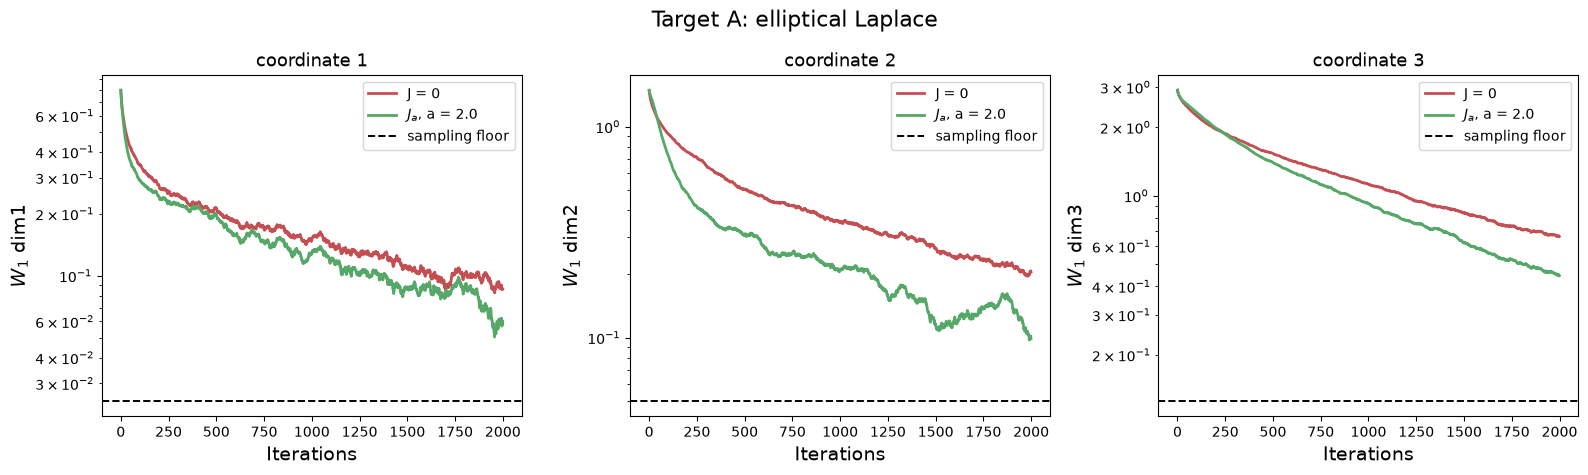

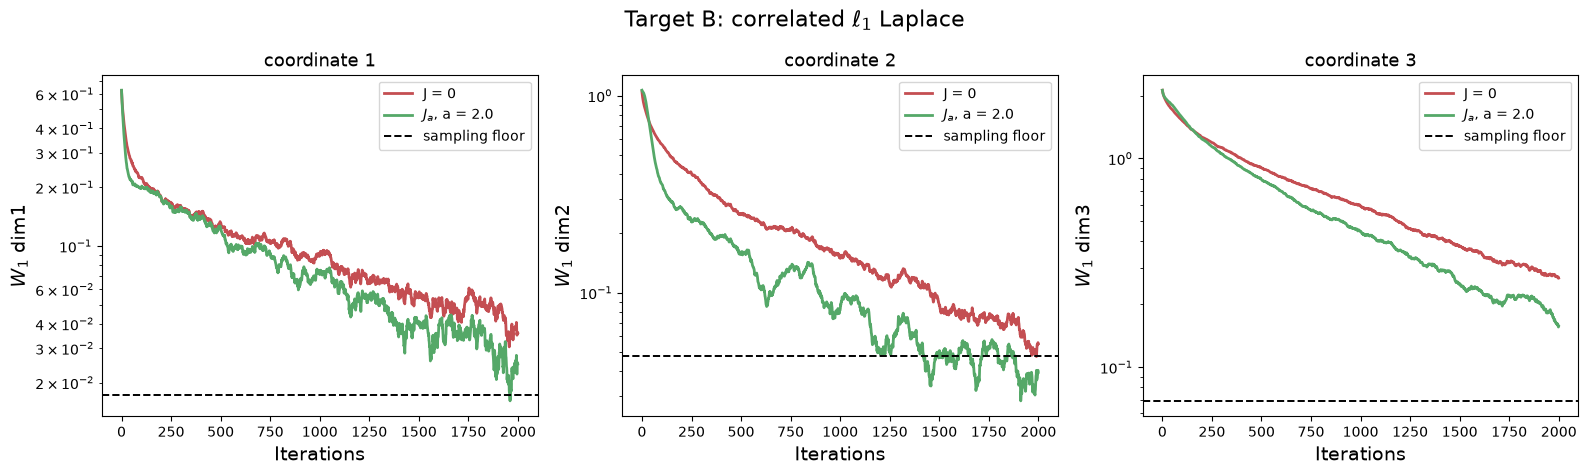

In [7]:
for kind, title in TARGETS.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    for i, ax in enumerate(axes):
        for a in [0.0, A_MAIN]:
            ax.plot(exp1[kind][a]["W1"][:, i], linewidth=2, color=COLORS[a],
                    label="J = 0" if a == 0 else "$J_a$, a = {}".format(a))
        ax.axhline(floors[kind][i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
        ax.set_yscale("log")
        ax.set_xlabel("Iterations", fontsize=14)
        ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
        ax.set_title("coordinate {}".format(i + 1), fontsize=13)
        ax.legend(fontsize=10)
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig("figures/mv_w1_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

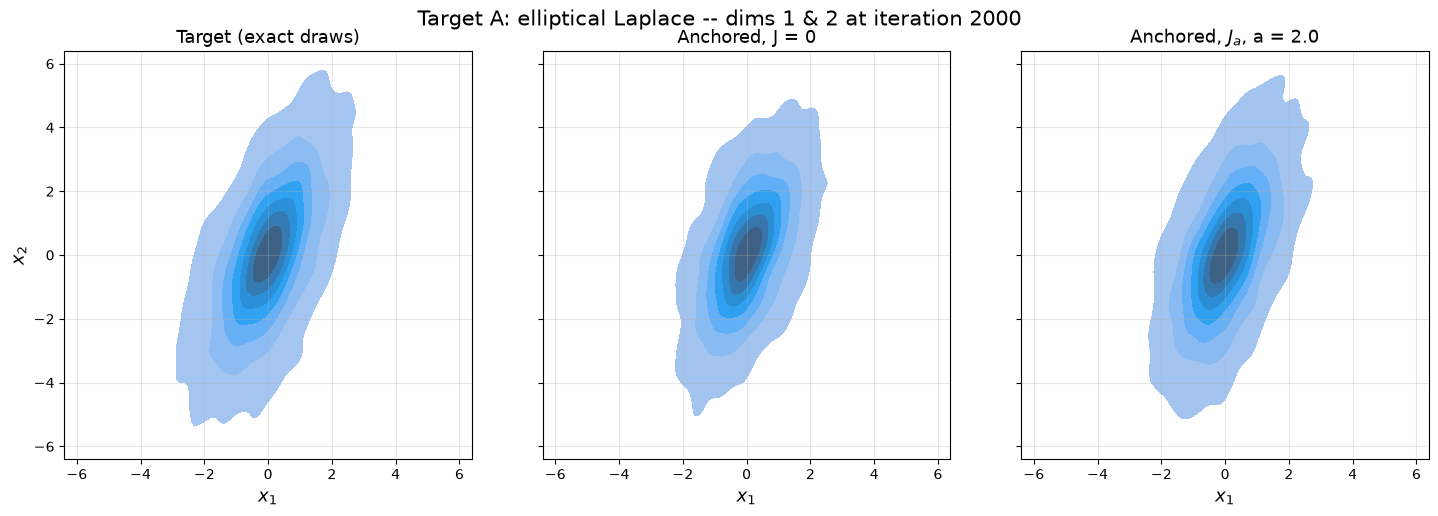

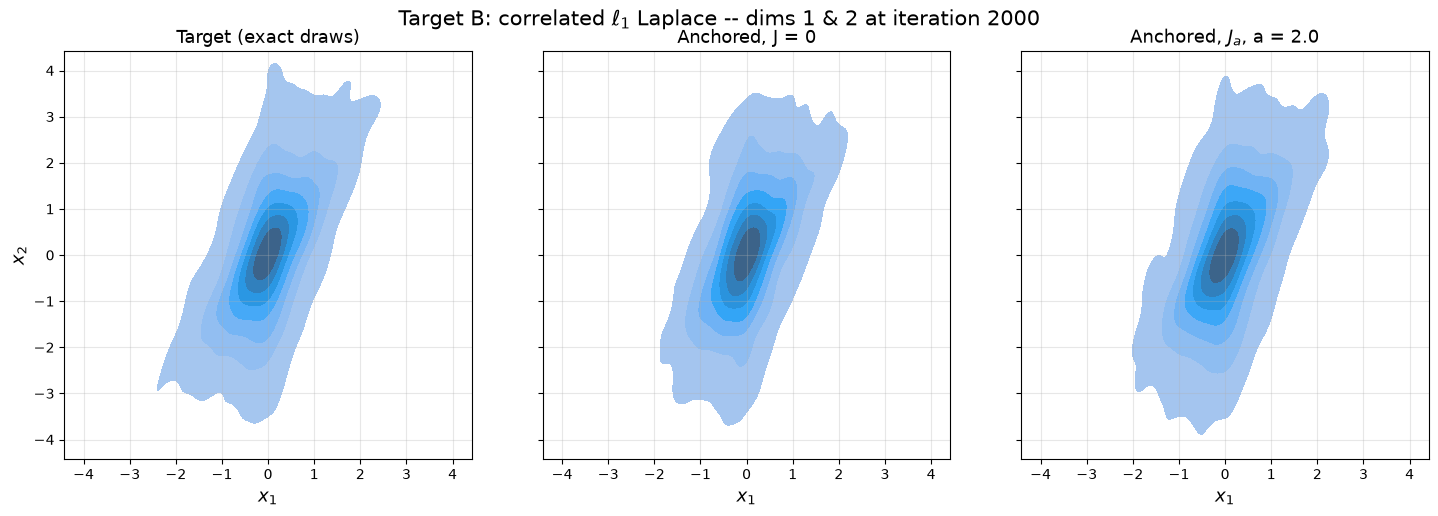

In [8]:
# 2D density contours (dims 1 & 2), in the style of the original Gaussian notebook
for kind, title in TARGETS.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
    panels = [("Target (exact draws)", refs[kind]),
              ("Anchored, J = 0", exp1[kind][0.0]["x"]),
              ("Anchored, $J_a$, a = {}".format(A_MAIN), exp1[kind][A_MAIN]["x"])]
    lim = 3.2 * refs[kind][:, :2].std(axis=0).max()
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.set_title(name, fontsize=13)
        ax.set_xlabel("$x_1$", fontsize=13)
        ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("$x_2$", fontsize=13)
    fig.suptitle(title + " -- dims 1 & 2 at iteration {}".format(max_iter), fontsize=15)
    plt.tight_layout()
    plt.savefig("figures/mv_density_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

### Invariance check at stationarity

The plots above stop while the chains are still moving, so they cannot say whether $J$ changed the
*target*. Rerun both with a longer horizon ($\eta=10^{-2}$, 4000 iterations) so that both reach
stationarity, and compare.

In [9]:
print("{:<6}{:<8}{:>28}{:>28}".format("target", "a", "W1 (dim1, dim2, dim3)", "KS (dim1, dim2, dim3)"))
print("-" * 74)
stat = {}
for kind in TARGETS:
    stat[kind] = {}
    for a in [0.0, A_MAIN]:
        xf, _ = run_chain(kind, L3, a, 1e-2, 4000, ref=refs[kind], track=False)
        stat[kind][a] = xf
        w  = [wasserstein_distance(refs[kind][:, i], xf[:, i]) for i in range(3)]
        ks = [ks_2samp(refs[kind][:, i], xf[:, i]).statistic for i in range(3)]
        print("{:<6}{:<8}".format(kind, a)
              + "{:>28}".format(np.array2string(np.round(w, 4)))
              + "{:>28}".format(np.array2string(np.round(ks, 4))))
    print("{:<6}{:<8}".format(kind, "floor") + "{:>28}".format(np.array2string(np.round(floors[kind], 4))))

targeta              W1 (dim1, dim2, dim3)       KS (dim1, dim2, dim3)
--------------------------------------------------------------------------


ell   0.0           [0.0226 0.0521 0.0926]      [0.013  0.0158 0.0182]


ell   2.0           [0.0281 0.034  0.1027]      [0.0138 0.0102 0.014 ]
ell   floor         [0.0247 0.0501 0.1257]


l1    0.0           [0.0216 0.0392 0.0515]      [0.0216 0.0144 0.013 ]


l1    2.0           [0.0273 0.0803 0.0632]      [0.0198 0.0322 0.0188]
l1    floor         [0.0173 0.0479 0.069 ]


## Experiment 2 — sweep over the skew strength $a$

In [10]:
A_SWEEP = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]

sweep = {}
for kind in TARGETS:
    sweep[kind] = {}
    for a in A_SWEEP:
        _, W = run_chain(kind, L3, a, eta, max_iter, ref=refs[kind])
        sweep[kind][a] = W[-100:].mean(axis=0)
    print(kind, {a: np.round(sweep[kind][a], 4).tolist() for a in A_SWEEP})

ell {0.0: [0.0922, 0.2074, 0.676], 0.5: [0.0838, 0.1588, 0.6601], 1.0: [0.0751, 0.1311, 0.5633], 2.0: [0.062, 0.119, 0.4611], 4.0: [0.0532, 0.09, 0.4177], 8.0: [0.0675, 0.1291, 0.394]}


l1 {0.0: [0.0399, 0.056, 0.2775], 0.5: [0.0327, 0.0428, 0.2632], 1.0: [0.0263, 0.0373, 0.2131], 2.0: [0.0245, 0.0353, 0.182], 4.0: [0.0268, 0.0724, 0.16], 8.0: [0.0691, 0.2535, 0.2017]}


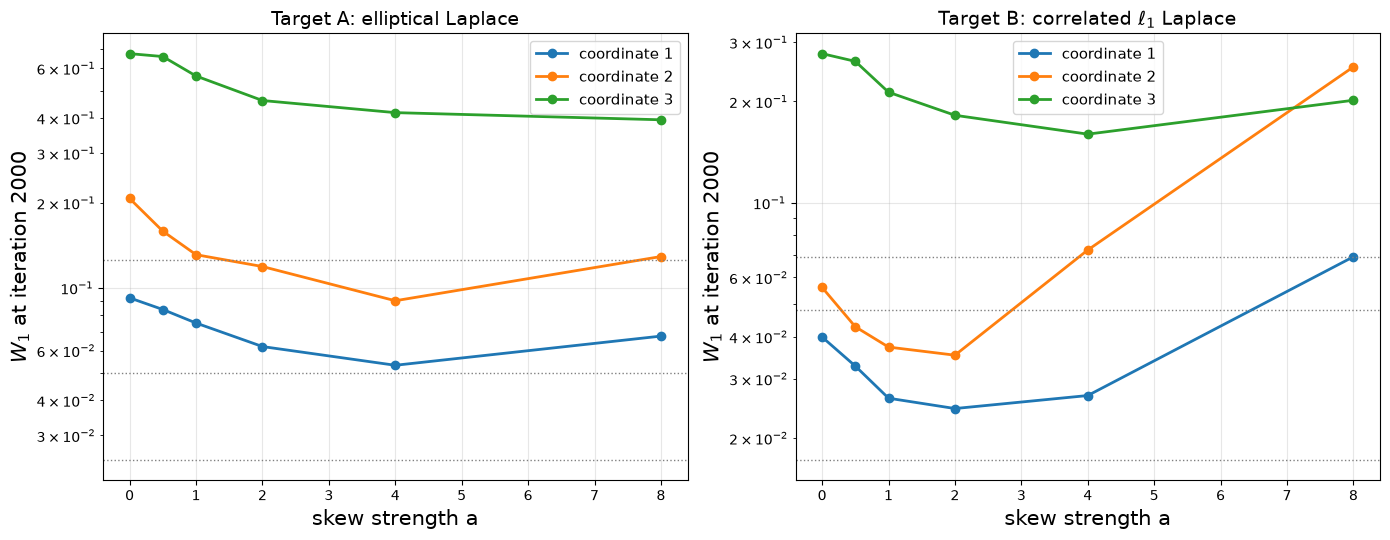

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (kind, title) in zip(axes, TARGETS.items()):
    for i in range(3):
        ax.plot(A_SWEEP, [sweep[kind][a][i] for a in A_SWEEP], marker="o", linewidth=2,
                label="coordinate {}".format(i + 1))
        ax.axhline(floors[kind][i], linestyle=":", linewidth=1, color="gray")
    ax.set_yscale("log")
    ax.set_xlabel("skew strength a", fontsize=15)
    ax.set_ylabel("$W_1$ at iteration {}".format(max_iter), fontsize=15)
    ax.set_title(title, fontsize=14)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/mv_sweep_a.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 3 — is the speed-up real, or just a bigger effective step?

The non-reversible drift is $-(I+J)\nabla U_0 e^{\Delta}$, whose magnitude grows with $a$. At a fixed
$\eta$ that means larger displacements per iteration, so a fair comparison has to separate "$J$ accelerates
the diffusion" from "$J$ inflates the Euler step".

Control: hold the **physical time** $T=\eta\cdot n_{\text{steps}}$ fixed at 10 and refine $\eta$. As
$\eta\to0$ both chains approach their continuous-time laws at time $T$; if the gap between $a=0$ and $a=2$
survives, it belongs to the SDE and not to the discretization.

In [12]:
T_FIX = 10.0
refine = [(5e-3, 2000), (2.5e-3, 4000), (1.25e-3, 8000)]

print("W1 at fixed physical time T = {}".format(T_FIX))
print("{:<6}{:<12}{:<8}{:>30}".format("target", "eta", "a", "W1 (dim1, dim2, dim3)"))
print("-" * 60)
control = {}
for kind in TARGETS:
    control[kind] = {}
    for eta_r, n_r in refine:
        for a in [0.0, A_MAIN]:
            xf, _ = run_chain(kind, L3, a, eta_r, n_r, ref=refs[kind], track=False)
            w = [wasserstein_distance(refs[kind][:, i], xf[:, i]) for i in range(3)]
            control[kind][(eta_r, a)] = w
            print("{:<6}{:<12}{:<8}".format(kind, eta_r, a) + "{:>30}".format(np.array2string(np.round(w, 4))))

W1 at fixed physical time T = 10.0
targeteta         a                W1 (dim1, dim2, dim3)
------------------------------------------------------------


ell   0.005       0.0             [0.0863 0.2043 0.6623]


ell   0.005       2.0             [0.0601 0.0987 0.4448]


ell   0.0025      0.0             [0.0837 0.2034 0.6629]


ell   0.0025      2.0             [0.0546 0.1242 0.4563]


...

l1    0.005       2.0             [0.0249 0.0394 0.1567]


l1    0.0025      0.0             [0.0382 0.0626 0.2697]


l1    0.0025      2.0             [0.0221 0.0243 0.1528]


l1    0.00125     0.0             [0.0424 0.0729 0.2853]


l1    0.00125     2.0             [0.0295 0.0325 0.1607]


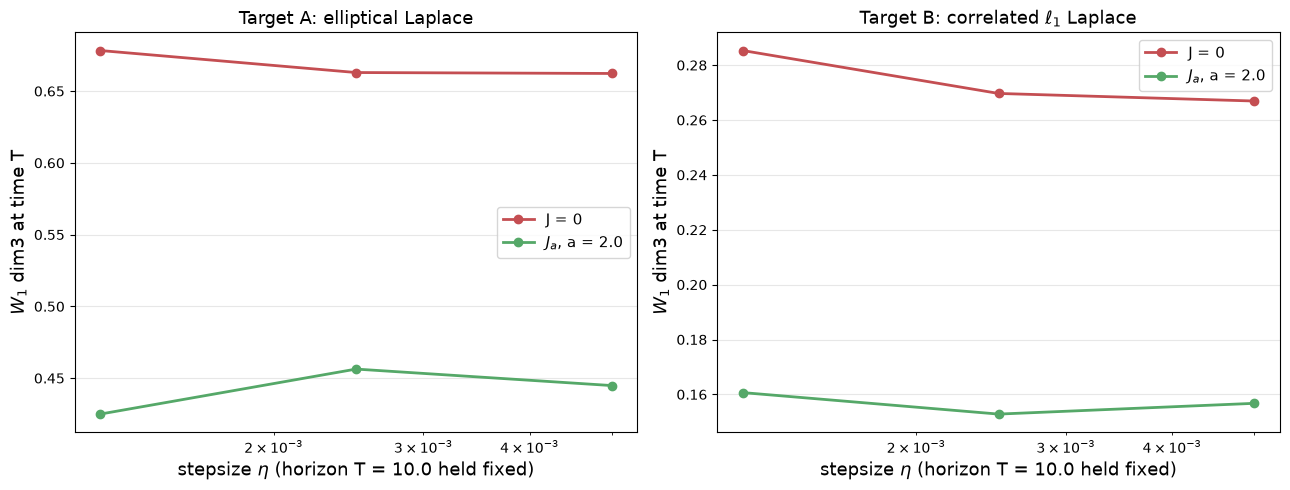

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
etas = [e for e, _ in refine]
for ax, (kind, title) in zip(axes, TARGETS.items()):
    for a in [0.0, A_MAIN]:
        ax.plot(etas, [control[kind][(e, a)][2] for e in etas], marker="o", linewidth=2,
                color=COLORS[a], label="J = 0" if a == 0 else "$J_a$, a = {}".format(a))
    ax.set_xscale("log")
    ax.set_xlabel(r"stepsize $\eta$ (horizon T = {} held fixed)".format(T_FIX), fontsize=13)
    ax.set_ylabel("$W_1$ dim3 at time T", fontsize=13)
    ax.set_title(title, fontsize=13)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/mv_control_fixed_time.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 4 — does the gain survive in higher dimension?

Target A with $d\in\{2,3,5,10\}$, scales spread geometrically over $[0.5,2]$ and the same $\rho=0.6$.
Reported per dimension is the coordinate-averaged relative error $\frac1d\sum_i W_1^{(i)}/\sigma_i$, which
is comparable across $d$, at a fixed horizon.

In [14]:
DIMS = [2, 3, 5, 10]
rng4 = np.random.default_rng(SEED)

rel = {0.0: [], A_MAIN: []}
flr = []
for d in DIMS:
    scales = np.geomspace(0.5, 2.0, d)
    Ld = make_L(d, scales, RHO)
    ref_d = sample_target("ell", Ld, N, rng4)
    sd = ref_d.std(axis=0)
    flr.append(np.mean(np.array(w1_floor(ref_d, "ell", Ld, N, rng4, reps=5)) / sd))
    for a in [0.0, A_MAIN]:
        xf, _ = run_chain("ell", Ld, a, eta, max_iter, ref=ref_d, track=False)
        w = np.array([wasserstein_distance(ref_d[:, i], xf[:, i]) for i in range(d)])
        rel[a].append(float(np.mean(w / sd)))
    print("d = {:<3} floor = {:.4f}   a=0 -> {:.4f}   a={} -> {:.4f}  (ratio {:.2f}x)".format(
        d, flr[-1], rel[0.0][-1], A_MAIN, rel[A_MAIN][-1], rel[0.0][-1] / rel[A_MAIN][-1]))

d = 2   floor = 0.0284   a=0 -> 0.0883   a=2.0 -> 0.0350  (ratio 2.52x)


d = 3   floor = 0.0292   a=0 -> 0.1210   a=2.0 -> 0.0730  (ratio 1.66x)


d = 5   floor = 0.0245   a=0 -> 0.1906   a=2.0 -> 0.1418  (ratio 1.34x)


d = 10  floor = 0.0262   a=0 -> 0.2815   a=2.0 -> 0.2590  (ratio 1.09x)


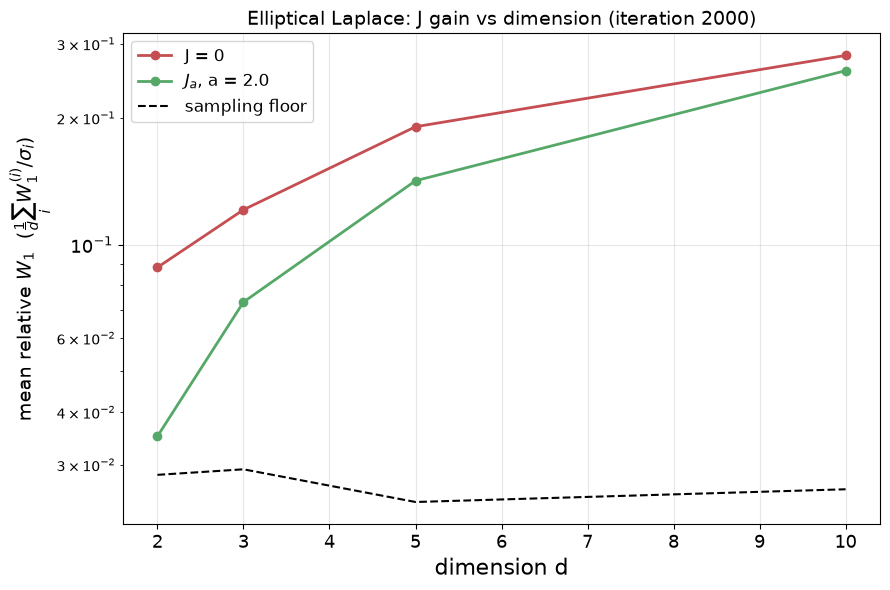

In [15]:
plt.figure(figsize=(9, 6))
for a in [0.0, A_MAIN]:
    plt.plot(DIMS, rel[a], marker="o", linewidth=2, color=COLORS[a],
             label="J = 0" if a == 0 else "$J_a$, a = {}".format(a))
plt.plot(DIMS, flr, "k--", linewidth=1.5, label="sampling floor")
plt.yscale("log")
plt.xlabel("dimension d", fontsize=16)
plt.ylabel(r"mean relative $W_1$  ($\frac{1}{d}\sum_i W_1^{(i)}/\sigma_i$)", fontsize=14)
plt.title("Elliptical Laplace: J gain vs dimension (iteration {})".format(max_iter), fontsize=14)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/mv_dimension.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**Which multivariate Laplace matters for this project.** The two standard constructions differ in the
dimension of their non-smooth set, and that difference dominates everything else here. Target A's kink is
the single point $x=0$, which an ensemble in $d=3$ essentially never visits, so the smoothed anchor sits
almost exactly on top of $U$: measured on target draws, $\Delta=U-U_0\in[-0.029,-0.0005]$, i.e.
$e^{\Delta}\in[0.971,0.9995]$. Target B's kinks live on $d$ hyperplanes that the chain crosses constantly,
and even there $\Delta\in[-0.19,-0.004]$. In both cases the anchored reweighting is nearly trivial and
**no clamping of $e^{\Delta}$ is needed at all** — in sharp contrast to the zero anchor of the first
notebook, which diverged. Smoothing the kink is enough; the correction it needs is tiny.

**$J$ accelerates both targets, by a similar factor** ($\eta=5\times10^{-3}$, iteration 2000,
$W_1$ per coordinate):

| target | $a=0$ | $a=2$ | gain on dim3 |
|---|---|---|---|
| A, elliptical | $(0.092,\,0.207,\,0.676)$ | $(0.062,\,0.119,\,0.461)$ | $1.47\times$ |
| B, correlated $\ell_1$ | $(0.040,\,0.056,\,0.278)$ | $(0.025,\,0.035,\,0.182)$ | $1.53\times$ |

The gain is on the same order as the $1.6\times$ seen for the uncorrelated product target, so correlation
($\rho=0.6$, $\mathrm{cond}\,\Sigma=34.6$) neither unlocks nor destroys the benefit at this anisotropy.

**The speed-up is a property of the SDE, not of the Euler step.** Because $(I+J)$ inflates the drift, a
larger $a$ moves particles further per iteration, so the comparison could have been an artefact. Holding
the physical time $T=\eta n$ fixed at 10 and refining $\eta$ by $4\times$ leaves the gap intact — Target A
dim3: $0.662\to0.678$ for $a=0$ against $0.445\to0.425$ for $a=2$; Target B dim3: $0.267\to0.285$ against
$0.157\to0.161$. The $a=0$ and $a=2$ curves are converging to *different* continuous-time laws at time $T$,
which is what non-reversible acceleration means.

**$J$ leaves the stationary law alone, as the invariance proof requires.** Run long enough to reach
stationarity ($\eta=10^{-2}$, 4000 iterations), both values of $a$ land at the sampling floor with KS
statistics of $0.010$–$0.032$ on every coordinate, and the 2D contours are indistinguishable from exact
draws. $J$ buys rate, not accuracy — and past the optimum it costs accuracy: at $a=8$ Target B degrades to
$(0.069,0.254,0.202)$, worse than $a=0$ on the two fast coordinates. Best compromise was $a\approx2$–$4$
for both targets.

**The gain shrinks as dimension grows** (Target A, coordinate-averaged relative $W_1$ at iteration 2000):

| $d$ | 2 | 3 | 5 | 10 |
|---|---|---|---|---|
| gain from $a=2$ | $2.52\times$ | $1.66\times$ | $1.34\times$ | $1.09\times$ |

This is a property of *this* $J$, not of non-reversibility in general: $J_a$ is tridiagonal, so it couples
each coordinate only to its two neighbours, and the fraction of the space it stirs falls as $d$ grows. A
denser or cyclic skew matrix — or a state-dependent one, as in the Gaussian notebook's $J_g$ — is the
natural next thing to test if higher dimensions are the target.